# Msingi v11: Swahili Neural Vocoder — Fresh Start

Full Phase 1 + Phase 2 rebuild. No v10 inheritance. Volume subdivision under `/mnt/sauti/v11/` keeps this isolated from finetuning notebooks and future WAXAL work.

## Volume layout
```
sauti-tts-volume/v11/
├── text/            # wiki_sw.txt, culturax_sw_bulk.txt, ss_gold.txt
├── tokenizer/       # MsingiTokens BPE: tokenizer.json, vocab.json
├── audio/           # MCV 25.0 tarball
├── manifest/        # phase1_manifest.jsonl, phase1_manifest_sorted.jsonl
└── checkpoints/     # gen_NNNNNN.pt, mpd_NNNNNN.pt, msd_NNNNNN.pt
```

## Phases
- **Phase 1**: Text ingest → fluency filter → BPE tokenizer → audio → manifest. Cells 2-7.
- **Phase 2**: BigVGAN GAN fine-tune 0→100k, full objective (MRSTFT + MPD + MSD + fmap). Cells 8-9. Spawned.
- **Phase 3**: WAXAL alignment. Future notebook.

## Lessons baked in
- Streaming tar iteration, no RAM load
- Full GAN objective from step 1 (no STFT-only collapse)
- Custom MPD/MSD, no library deps
- `.spawn()` detached + resumable ckpts
- W&B deterministic ID for reconnect


In [1]:
import os, modal
modal.enable_output()

V11 = "/mnt/sauti/v11"
CONFIG = {
    "vol_mount": "/mnt/sauti",
    "text_dir": f"{V11}/text", "tok_dir": f"{V11}/tokenizer",
    "audio_dir": f"{V11}/audio", "manifest_dir": f"{V11}/manifest",
    "ckpt_dir": f"{V11}/checkpoints",
    # Phase 1
    "wiki_lines": 30_000, "culturax_lines": 500_000, "fluency_threshold": 0.80,
    "mdc_dataset_id": "cmn3ailbd008nmb07mjyu3xro",
    "vocab_size": 32_000, "min_frequency": 2,
    # Phase 2
    "bigvgan_repo": "nvidia/bigvgan_v2_24khz_100band_256x",
    "sample_rate": 24000, "n_fft": 1024, "hop_length": 256,
    "win_length": 1024, "n_mels": 100, "fmin": 0, "fmax": 12000,
    "clip_seconds": 1.0, "target_step": 100_000,
    "gen_lr": 1e-4, "disc_lr": 1e-4, "betas": (0.8, 0.99),
    "w_stft": 45.0, "w_fmap": 2.0, "w_gen_adv": 1.0,
    "grad_clip": 1.0, "save_every": 500, "log_every": 10, "keep_last_n": 10,
    "wandb_project": "sauti-ya-kenya", "wandb_run_name": "msingi-v11-fresh",
    "gpu": "H100", "timeout_hours": 23,
}

text_image = (modal.Image.debian_slim(python_version="3.12")
    .pip_install("datasets", "huggingface_hub", "tqdm", "tokenizers"))
audio_image = (modal.Image.debian_slim(python_version="3.12")
    .pip_install("requests", "tqdm", "pandas", "tokenizers"))
train_image = (modal.Image.debian_slim(python_version="3.12")
    .apt_install("libsndfile1", "ffmpeg", "ninja-build", "gcc", "g++")
    .pip_install("torch", "torchaudio", "librosa", "soundfile",
                 "bigvgan", "auraloss", "wandb", "tqdm",
                 "huggingface_hub", "hf_transfer"))

app = modal.App("msingi-v11")
vol = modal.Volume.from_name("sauti-tts-volume", create_if_missing=True)
print("Ready. V11 root: %s" % V11)


Ready. V11 root: /mnt/sauti/v11


In [2]:
@app.function(image=text_image, volumes={"/mnt/sauti": vol},
              secrets=[modal.Secret.from_name("hf-secret")], timeout=3600)
def p1_ingest_text():
    import os
    from datasets import load_dataset
    C = CONFIG
    os.makedirs(C["text_dir"], exist_ok=True)

    print("[1/2] Wikipedia SW anchor (%d lines)" % C["wiki_lines"])
    wiki = load_dataset("wikimedia/wikipedia", "20231101.sw", split="train", streaming=True)
    with open(f'{C["text_dir"]}/wiki_sw.txt', "w") as f:
        for i, ex in enumerate(wiki):
            f.write(ex["text"].replace("\n", " ") + "\n")
            if i >= C["wiki_lines"]: break

    print("[2/2] CulturaX SW bulk (%d lines)" % C["culturax_lines"])
    token = os.environ.get("HF_TOKEN")
    bulk = load_dataset("uonlp/CulturaX", "sw", split="train", streaming=True, token=token)
    with open(f'{C["text_dir"]}/culturax_sw_bulk.txt', "w") as f:
        for i, ex in enumerate(bulk):
            f.write(ex["text"].replace("\n", " ") + "\n")
            if i % 50000 == 0: print("  %d..." % i)
            if i >= C["culturax_lines"]: break
    vol.commit()
    print("Done.")

if __name__ == "__main__":
    with app.run():
        p1_ingest_text.remote()


In [3]:
@app.function(image=text_image, volumes={"/mnt/sauti": vol}, timeout=3600)
def p1_fluency_filter():
    import re
    from tqdm import tqdm
    C = CONFIG
    print("Building anchor lexicon from Wikipedia")
    anchor = set()
    with open(f'{C["text_dir"]}/wiki_sw.txt') as f:
        for line in f:
            anchor.update(re.findall(r'\b\w+\b', line.lower()))
    print("  %d unique words" % len(anchor))

    print("Filtering CulturaX (threshold=%.2f)" % C["fluency_threshold"])
    gold_count = 0
    with open(f'{C["text_dir"]}/culturax_sw_bulk.txt') as fin, \
         open(f'{C["text_dir"]}/ss_gold.txt', "w") as fout:
        for line in tqdm(fin):
            words = re.findall(r'\b\w+\b', line.lower())
            if not words: continue
            score = sum(1 for w in words if w in anchor) / len(words)
            if score >= C["fluency_threshold"]:
                fout.write(line)
                gold_count += 1
    vol.commit()
    print("Gold: %d lines" % gold_count)

if __name__ == "__main__":
    with app.run():
        p1_fluency_filter.remote()


In [4]:
@app.function(image=text_image, volumes={"/mnt/sauti": vol}, timeout=3600)
def p1_train_tokenizer():
    import os, json
    from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
    C = CONFIG
    os.makedirs(C["tok_dir"], exist_ok=True)

    tok = Tokenizer(models.BPE())
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
    tok.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(
        vocab_size=C["vocab_size"], min_frequency=C["min_frequency"],
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
        special_tokens=["<pad>", "<unk>", "<s>", "</s>"],
    )
    corpus = [f'{C["text_dir"]}/ss_gold.txt', f'{C["text_dir"]}/wiki_sw.txt']
    print("Training BPE on:", corpus)
    tok.train(corpus, trainer)
    tok.save(f'{C["tok_dir"]}/tokenizer.json')
    print("Vocab: %d tokens" % tok.get_vocab_size())

    with open(f'{C["tok_dir"]}/vocab.json', "w") as f:
        json.dump(tok.get_vocab(), f, indent=2, ensure_ascii=False)

    sample = "Habari ya leo, ninafuraha kukusikia"
    ids = tok.encode(sample).ids
    print("Sample: '%s' -> %d tokens: %s" % (sample, len(ids), ids[:10]))
    vol.commit()

if __name__ == "__main__":
    with app.run():
        p1_train_tokenizer.remote()


In [6]:
@app.function(
    image=(modal.Image.debian_slim(python_version="3.12")
           .pip_install("datacollective", "tqdm")),
    volumes={"/mnt/sauti": vol},
    secrets=[modal.Secret.from_name("mozilla-secret")],
    timeout=7200,
)
def p1_download_audio():
    import os
    os.environ["MDC_API_URL"] = "https://datacollective.mozillafoundation.org/api"
    os.environ["MDC_DOWNLOAD_PATH"] = CONFIG["audio_dir"]

    os.makedirs(CONFIG["audio_dir"], exist_ok=True)

    from datacollective import download_dataset
    print("Downloading MDC dataset: %s" % CONFIG["mdc_dataset_id"])
    result = download_dataset(CONFIG["mdc_dataset_id"])
    print("Downloaded: %s" % result)

    vol.commit()
    print("Saved to %s" % CONFIG["audio_dir"])
    return str(result)

if __name__ == "__main__":
    with app.run():
        p1_download_audio.remote()

In [7]:
@app.function(image=audio_image, volumes={"/mnt/sauti": vol}, timeout=3600)
def p1_build_manifest():
    import os, json, tarfile
    import pandas as pd
    from tokenizers import Tokenizer
    from tqdm import tqdm
    C = CONFIG
    os.makedirs(C["manifest_dir"], exist_ok=True)

    tok = Tokenizer.from_file(f'{C["tok_dir"]}/tokenizer.json')
    print("Tokenizer: %d vocab" % tok.get_vocab_size())

    tarball = [f for f in os.listdir(C["audio_dir"]) if f.endswith(".tar.gz")][0]
    tar_path = f'{C["audio_dir"]}/{tarball}'
    target_tsv = "cv-corpus-25.0-2026-03-09/sw/validated.tsv"

    print("Extracting %s" % target_tsv)
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extract(tar.getmember(target_tsv), path=C["audio_dir"])
        df = pd.read_csv(f'{C["audio_dir"]}/{target_tsv}', sep="\t")
    print("Validated: %d" % len(df))

    unsorted_path = f'{C["manifest_dir"]}/phase1_manifest.jsonl'
    with open(unsorted_path, "w") as f:
        for _, row in tqdm(df.iterrows(), total=len(df)):
            text = str(row["sentence"]).lower()
            ids = tok.encode(text).ids
            entry = {
                "audio_path": f'{C["audio_dir"]}/cv-corpus-25.0-2026-03-09/sw/clips/{row["path"]}',
                "text": text, "msingi_tokens": ids,
                "up_votes": int(row.get("up_votes", 0) or 0),
                "gender": str(row.get("gender", "unknown") or "unknown"),
            }
            f.write(json.dumps(entry) + "\n")

    print("Indexing tar order")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar_order = {m.name: i for i, m in enumerate(tar.getmembers())}

    with open(unsorted_path) as f:
        samples = [json.loads(l) for l in f]

    def idx(s):
        key = "/".join(s["audio_path"].split("/")[-4:])
        return tar_order.get(key, 10**9)
    samples.sort(key=idx)

    sorted_path = f'{C["manifest_dir"]}/phase1_manifest_sorted.jsonl'
    with open(sorted_path, "w") as f:
        for s in samples:
            f.write(json.dumps(s) + "\n")
    vol.commit()
    print("Sorted: %d -> %s" % (len(samples), sorted_path))

if __name__ == "__main__":
    with app.run():
        p1_build_manifest.remote()


In [8]:
@app.function(image=train_image, volumes={"/mnt/sauti": vol}, timeout=300)
def p1_sanity():
    import os
    C = CONFIG
    paths = [
        ("Wiki anchor", f'{C["text_dir"]}/wiki_sw.txt'),
        ("Gold fluent", f'{C["text_dir"]}/ss_gold.txt'),
        ("MsingiTokens", f'{C["tok_dir"]}/tokenizer.json'),
        ("Sorted manifest", f'{C["manifest_dir"]}/phase1_manifest_sorted.jsonl'),
    ]
    print("Phase 1 artifacts")
    for label, p in paths:
        ok = os.path.exists(p)
        sz = os.path.getsize(p)/1e6 if ok else 0
        print("  [%s %.1f MB] %s" % ("OK" if ok else "MISS", sz, label))

    if os.path.exists(C["audio_dir"]):
        tb = [f for f in os.listdir(C["audio_dir"]) if f.endswith(".tar.gz")]
        print("  [%s] MCV tarball: %s" % ("OK" if tb else "MISS", tb[0] if tb else "-"))

    with open(f'{C["manifest_dir"]}/phase1_manifest_sorted.jsonl') as f:
        n = sum(1 for _ in f)
    print("Manifest entries: %d" % n)
    return "PASS"

if __name__ == "__main__":
    with app.run():
        p1_sanity.remote()


In [9]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.nn.utils import weight_norm, spectral_norm

class DiscriminatorP(nn.Module):
    def __init__(self, period, use_spectral=False):
        super().__init__()
        self.period = period
        nf = weight_norm if not use_spectral else spectral_norm
        self.convs = nn.ModuleList([
            nf(nn.Conv2d(1, 32, (5,1), (3,1), padding=(2,0))),
            nf(nn.Conv2d(32, 128, (5,1), (3,1), padding=(2,0))),
            nf(nn.Conv2d(128, 512, (5,1), (3,1), padding=(2,0))),
            nf(nn.Conv2d(512, 1024, (5,1), (3,1), padding=(2,0))),
            nf(nn.Conv2d(1024, 1024, (5,1), 1, padding=(2,0))),
        ])
        self.conv_post = nf(nn.Conv2d(1024, 1, (3,1), 1, padding=(1,0)))
    def forward(self, x):
        fmap = []
        b, c, t = x.shape
        if t % self.period:
            x = F.pad(x, (0, self.period - t%self.period), "reflect")
            t = x.shape[-1]
        x = x.view(b, c, t//self.period, self.period)
        for l in self.convs:
            x = F.leaky_relu(l(x), 0.1); fmap.append(x)
        x = self.conv_post(x); fmap.append(x)
        return torch.flatten(x, 1, -1), fmap

class MPD(nn.Module):
    def __init__(self):
        super().__init__()
        self.discs = nn.ModuleList([DiscriminatorP(p) for p in (2,3,5,7,11)])
    def forward(self, y, yh):
        rs, gs, fr, fg = [], [], [], []
        for d in self.discs:
            r, fmr = d(y); g, fmg = d(yh)
            rs.append(r); gs.append(g); fr.append(fmr); fg.append(fmg)
        return rs, gs, fr, fg

class DiscriminatorS(nn.Module):
    def __init__(self, use_spectral=False):
        super().__init__()
        nf = weight_norm if not use_spectral else spectral_norm
        self.convs = nn.ModuleList([
            nf(nn.Conv1d(1, 128, 15, 1, padding=7)),
            nf(nn.Conv1d(128, 128, 41, 2, groups=4, padding=20)),
            nf(nn.Conv1d(128, 256, 41, 2, groups=16, padding=20)),
            nf(nn.Conv1d(256, 512, 41, 4, groups=16, padding=20)),
            nf(nn.Conv1d(512, 1024, 41, 4, groups=16, padding=20)),
            nf(nn.Conv1d(1024, 1024, 41, 1, groups=16, padding=20)),
            nf(nn.Conv1d(1024, 1024, 5, 1, padding=2)),
        ])
        self.conv_post = nf(nn.Conv1d(1024, 1, 3, 1, padding=1))
    def forward(self, x):
        fmap = []
        for l in self.convs:
            x = F.leaky_relu(l(x), 0.1); fmap.append(x)
        x = self.conv_post(x); fmap.append(x)
        return torch.flatten(x, 1, -1), fmap

class MSD(nn.Module):
    def __init__(self):
        super().__init__()
        self.discs = nn.ModuleList([DiscriminatorS(True), DiscriminatorS(), DiscriminatorS()])
        self.pools = nn.ModuleList([nn.AvgPool1d(4,2,padding=2), nn.AvgPool1d(4,2,padding=2)])
    def forward(self, y, yh):
        rs, gs, fr, fg = [], [], [], []
        for i, d in enumerate(self.discs):
            if i > 0: y = self.pools[i-1](y); yh = self.pools[i-1](yh)
            r, fmr = d(y); g, fmg = d(yh)
            rs.append(r); gs.append(g); fr.append(fmr); fg.append(fmg)
        return rs, gs, fr, fg

class AttrDict(dict):
    def __getattr__(self, k): return self[k]

def get_mel(wav, device):
    import torchaudio
    C = CONFIG
    if wav.dim() == 1: wav = wav.unsqueeze(0)
    wav = wav.to(device)
    tfm = torchaudio.transforms.MelSpectrogram(
        sample_rate=C["sample_rate"], n_fft=C["n_fft"],
        win_length=C["win_length"], hop_length=C["hop_length"],
        f_min=C["fmin"], f_max=C["fmax"], n_mels=C["n_mels"],
        center=False, power=1.0, normalized=False,
    ).to(device)
    return torch.log(torch.clamp(tfm(wav), min=1e-5))

print("MPD + MSD + mel ready")


MPD + MSD + mel ready


In [16]:
@app.function(
    image=train_image, gpu=CONFIG["gpu"], memory=64_000,
    volumes={"/mnt/sauti": vol},
    timeout=CONFIG["timeout_hours"]*3600,
    secrets=[modal.Secret.from_name("wandb-secret"),
             modal.Secret.from_name("hf-secret")],
)
def p2_train():
    import os, json, tarfile, io, glob, traceback, torch, librosa, wandb, auraloss
    from tqdm import tqdm
    from huggingface_hub import hf_hub_download
    from bigvgan import BigVGAN

    C = CONFIG
    os.makedirs(C["ckpt_dir"], exist_ok=True)
    device = "cuda"
    wandb.init(project=C["wandb_project"], name=C["wandb_run_name"],
               config=C, resume="allow", id=C["wandb_run_name"])

    print("Loading BigVGAN config")
    cfg_path = hf_hub_download(repo_id=C["bigvgan_repo"], filename="config.json")
    with open(cfg_path) as f:
        h = AttrDict(json.load(f))
    gen = BigVGAN(h).to(device)

    ckpts = sorted(glob.glob(f'{C["ckpt_dir"]}/gen_*.pt'))
    if ckpts:
        start_step = int(ckpts[-1].split("_")[-1].split(".")[0])
        print("Resuming v11 step %d" % start_step)
        gen.load_state_dict(torch.load(ckpts[-1], map_location=device))
    else:
        pre = hf_hub_download(repo_id=C["bigvgan_repo"], filename="bigvgan_generator.pt")
        gen.load_state_dict(torch.load(pre, map_location=device)["generator"])
        start_step = 0
        print("Started from BigVGAN pretrained")

    mpd = MPD().to(device); msd = MSD().to(device)
    for name, m in [("mpd", mpd), ("msd", msd)]:
        dp = f'{C["ckpt_dir"]}/{name}_{start_step:06d}.pt'
        if os.path.exists(dp):
            m.load_state_dict(torch.load(dp, map_location=device))

    opt_g = torch.optim.AdamW(gen.parameters(), lr=C["gen_lr"], betas=C["betas"])
    opt_d = torch.optim.AdamW(list(mpd.parameters()) + list(msd.parameters()),
                              lr=C["disc_lr"], betas=C["betas"])
    stft = auraloss.freq.MultiResolutionSTFTLoss().to(device)

    manifest_path = f'{C["manifest_dir"]}/phase1_manifest_sorted.jsonl'
    validated = {}
    with open(manifest_path) as f:
        for line in f:
            s = json.loads(line)
            validated[os.path.basename(s["audio_path"])] = True
    print("Manifest: %d" % len(validated))

    tarballs = [f for f in os.listdir(C["audio_dir"]) if f.endswith(".tar.gz")]
    tar_path = f'{C["audio_dir"]}/{tarballs[0]}'
    clip_samples = int(C["sample_rate"] * C["clip_seconds"])

    gen.train(); mpd.train(); msd.train()
    step = start_step
    pbar = tqdm(total=C["target_step"], initial=start_step, desc="Phase 2")
    first_error_logged = False

    with tarfile.open(tar_path, mode="r:gz") as tar:
        for member in tar:
            if step >= C["target_step"]: break
            if not member.isfile(): continue
            if os.path.basename(member.name) not in validated: continue
            try:
                buf = tar.extractfile(member).read()
                audio, _ = librosa.load(io.BytesIO(buf), sr=C["sample_rate"])
                if len(audio) < clip_samples: continue
                audio = audio[:clip_samples]

                # y: (B=1, C=1, T)
                y = torch.FloatTensor(audio).unsqueeze(0).unsqueeze(0).to(device)
                mel = get_mel(y.squeeze(1), device)
                y_hat = gen(mel)

                # Normalize generator output to (B, 1, T) — BigVGAN returns (B, T)
                if y_hat.dim() == 2:
                    y_hat = y_hat.unsqueeze(1)

                tl = min(y_hat.shape[-1], y.shape[-1])
                y_c, yh_c = y[:, :, :tl], y_hat[:, :, :tl]

                # ===== Discriminator step =====
                opt_d.zero_grad()
                rm, gm, _, _ = mpd(y_c, yh_c.detach())
                rs, gs, _, _ = msd(y_c, yh_c.detach())
                ld = sum(torch.mean((r-1)**2)+torch.mean(g**2) for r,g in zip(rm,gm))
                ld = ld + sum(torch.mean((r-1)**2)+torch.mean(g**2) for r,g in zip(rs,gs))
                ld.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(mpd.parameters())+list(msd.parameters()), C["grad_clip"])
                opt_d.step()

                # ===== Generator step =====
                opt_g.zero_grad()
                # auraloss MultiResolutionSTFTLoss wants (B, C, T) — keep 3D
                l_stft = stft(yh_c, y_c)
                rm, gm, frm, fgm = mpd(y_c, yh_c)
                rs, gs, frs, fgs = msd(y_c, yh_c)
                l_adv = sum(torch.mean((g-1)**2) for g in gm+gs)
                l_fmap = 0.0
                for frset, fgset in zip(frm+frs, fgm+fgs):
                    for fr, fg in zip(frset, fgset):
                        l_fmap = l_fmap + torch.mean(torch.abs(fr-fg))
                lg = C["w_stft"]*l_stft + C["w_gen_adv"]*l_adv + C["w_fmap"]*l_fmap
                lg.backward()
                torch.nn.utils.clip_grad_norm_(gen.parameters(), C["grad_clip"])
                opt_g.step()

                step += 1
                pbar.update(1)

                if step % C["log_every"] == 0:
                    wandb.log({"step": step,
                               "loss/d": float(ld), "loss/g": float(lg),
                               "loss/g_stft": float(l_stft),
                               "loss/g_adv": float(l_adv),
                               "loss/g_fmap": float(l_fmap)}, step=step)

                if step % C["save_every"] == 0:
                    torch.save(gen.state_dict(), f'{C["ckpt_dir"]}/gen_{step:06d}.pt')
                    torch.save(mpd.state_dict(), f'{C["ckpt_dir"]}/mpd_{step:06d}.pt')
                    torch.save(msd.state_dict(), f'{C["ckpt_dir"]}/msd_{step:06d}.pt')
                    for pat in ("gen_", "mpd_", "msd_"):
                        old = sorted(glob.glob(f'{C["ckpt_dir"]}/{pat}*.pt'))[:-C["keep_last_n"]]
                        for p in old: os.remove(p)
                    vol.commit()
                    print("saved step %d | g=%.4f d=%.4f" % (step, float(lg), float(ld)))

            except Exception as e:
                if not first_error_logged:
                    print("FIRST ERROR (full traceback follows):")
                    traceback.print_exc()
                    first_error_logged = True
                else:
                    print("skip (step %d): %s" % (step, e))
                continue

    wandb.finish()
    return step


if __name__ == "__main__":
    app.deploy()
    import modal
    fn = modal.Function.from_name("msingi-v11", "p2_train")
    call = fn.spawn()
    print("SPAWNED on DEPLOYED app. Call ID: %s" % call.object_id)
    print("Reconnect: modal.FunctionCall.from_id('%s').get(timeout=0)" % call.object_id)

SPAWNED on DEPLOYED app. Call ID: fc-01KP6XDCT121X5502DRHERGGSZ
Reconnect: modal.FunctionCall.from_id('fc-01KP6XDCT121X5502DRHERGGSZ').get(timeout=0)


In [7]:
import modal
CALL_ID = "fc-01KP6X1GKKFRNACC4C2P8DNK71"

def check():
    try:
        r = modal.FunctionCall.from_id(CALL_ID).get(timeout=0)
        print("Done. Final step: %s" % r)
    except TimeoutError:
        print("Running. Watch W&B.")
    except Exception as e:
        print(e)

@app.function(image=train_image, gpu="T4", volumes={"/mnt/sauti": vol})
def vocode_check(step=None):
    import os, json, glob, io, tarfile, torch, librosa, torchaudio, numpy as np
    from bigvgan import BigVGAN
    from huggingface_hub import hf_hub_download

    class AttrDict(dict):
        def __getattr__(self, k): return self[k]

    def _get_mel(wav, device):
        if wav.dim() == 1: wav = wav.unsqueeze(0)
        wav = wav.to(device)
        tfm = torchaudio.transforms.MelSpectrogram(
            sample_rate=CONFIG["sample_rate"], n_fft=CONFIG["n_fft"],
            win_length=CONFIG["win_length"], hop_length=CONFIG["hop_length"],
            f_min=CONFIG["fmin"], f_max=CONFIG["fmax"], n_mels=CONFIG["n_mels"],
            center=False, power=1.0, normalized=False,
        ).to(device)
        return torch.log(torch.clamp(tfm(wav), min=1e-5))

    C = CONFIG
    cfg = hf_hub_download(repo_id=C["bigvgan_repo"], filename="config.json")
    with open(cfg) as f:
        h = AttrDict(json.load(f))
    gen = BigVGAN(h).cuda().eval()

    if step:
        gp = f'{C["ckpt_dir"]}/gen_{step:06d}.pt'
    else:
        ck = sorted(glob.glob(f'{C["ckpt_dir"]}/gen_*.pt'))
        gp = ck[-1] if ck else None
    if not gp: raise FileNotFoundError("No checkpoint")
    print("Using:", gp)
    gen.load_state_dict(torch.load(gp, map_location="cuda"))

    with open(f'{C["manifest_dir"]}/phase1_manifest_sorted.jsonl') as f:
        s = json.loads(f.readline())
    key = os.path.basename(s["audio_path"])

    tarballs = [f for f in os.listdir(C["audio_dir"]) if f.endswith(".tar.gz")]
    with tarfile.open(f'{C["audio_dir"]}/{tarballs[0]}', "r:gz") as tar:
        for m in tar:
            if os.path.basename(m.name) == key:
                audio, _ = librosa.load(io.BytesIO(tar.extractfile(m).read()),
                                         sr=C["sample_rate"])
                break

    audio = audio[:C["sample_rate"]*3]
    y = torch.FloatTensor(audio).unsqueeze(0).cuda()
    with torch.no_grad():
        yh = gen(_get_mel(y, "cuda")).squeeze().cpu().numpy()

    return {"original": audio.astype(np.float32),
            "recon": yh.astype(np.float32),
            "text": s["text"]}

from IPython.display import Audio, display
print("Paste CALL_ID then check(). Use vocode_check.remote() after training produces ckpts.")


Paste CALL_ID then check(). Use vocode_check.remote() after training produces ckpts.


In [8]:
with app.run():
    r = vocode_check.remote()

print("Text:", r["text"])
print()
print("Original Common Voice clip:")
display(Audio(r["original"], rate=CONFIG["sample_rate"]))
print()
print("Msingi v11 reconstruction (step 100,000):")
display(Audio(r["recon"], rate=CONFIG["sample_rate"]))

Text: wanatokea katika afrika kusini kwa sahara tu, mara nyingi milimani.

Original Common Voice clip:



Msingi v11 reconstruction (step 100,000):


In [9]:
@app.function(image=train_image, gpu="T4", volumes={"/mnt/sauti": vol})
def vocode_audit(n_samples=5, seed=42):
    """Random N-clip audit instead of just the first manifest entry."""
    import os, json, glob, io, tarfile, torch, librosa, torchaudio, numpy as np, random
    from bigvgan import BigVGAN
    from huggingface_hub import hf_hub_download

    class AttrDict(dict):
        def __getattr__(self, k): return self[k]

    def _get_mel(wav, device):
        if wav.dim() == 1: wav = wav.unsqueeze(0)
        wav = wav.to(device)
        tfm = torchaudio.transforms.MelSpectrogram(
            sample_rate=CONFIG["sample_rate"], n_fft=CONFIG["n_fft"],
            win_length=CONFIG["win_length"], hop_length=CONFIG["hop_length"],
            f_min=CONFIG["fmin"], f_max=CONFIG["fmax"], n_mels=CONFIG["n_mels"],
            center=False, power=1.0, normalized=False,
        ).to(device)
        return torch.log(torch.clamp(tfm(wav), min=1e-5))

    C = CONFIG
    cfg = hf_hub_download(repo_id=C["bigvgan_repo"], filename="config.json")
    with open(cfg) as f:
        h = AttrDict(json.load(f))

    ck = sorted(glob.glob(f'{C["ckpt_dir"]}/gen_*.pt'))
    gen = BigVGAN(h).cuda().eval()
    gen.load_state_dict(torch.load(ck[-1], map_location="cuda"))
    print(f"Auditing with: {ck[-1]}")

    # Random sample N entries from manifest
    with open(f'{C["manifest_dir"]}/phase1_manifest_sorted.jsonl') as f:
        entries = [json.loads(l) for l in f]
    random.seed(seed)
    chosen = random.sample(entries, n_samples)
    chosen_keys = {os.path.basename(e["audio_path"]): e for e in chosen}

    results = []
    tarballs = [f for f in os.listdir(C["audio_dir"]) if f.endswith(".tar.gz")]
    with tarfile.open(f'{C["audio_dir"]}/{tarballs[0]}', "r:gz") as tar:
        for m in tar:
            key = os.path.basename(m.name)
            if key not in chosen_keys: continue
            try:
                audio, _ = librosa.load(io.BytesIO(tar.extractfile(m).read()),
                                         sr=C["sample_rate"])
                audio = audio[:C["sample_rate"]*3]
                if len(audio) < C["sample_rate"]: continue
                y = torch.FloatTensor(audio).unsqueeze(0).cuda()
                with torch.no_grad():
                    yh = gen(_get_mel(y, "cuda")).squeeze().cpu().numpy()

                # Quick perceptual metric: log-mel MAE
                n = min(len(audio), len(yh))
                og_mel = librosa.feature.melspectrogram(
                    y=audio[:n], sr=C["sample_rate"], n_mels=80,
                    n_fft=1024, hop_length=256)
                rec_mel = librosa.feature.melspectrogram(
                    y=yh[:n], sr=C["sample_rate"], n_mels=80,
                    n_fft=1024, hop_length=256)
                mel_mae = float(np.mean(np.abs(
                    np.log(og_mel + 1e-7) - np.log(rec_mel + 1e-7))))

                results.append({
                    "text": chosen_keys[key]["text"],
                    "gender": chosen_keys[key].get("gender", "?"),
                    "original": audio.astype(np.float32),
                    "recon": yh.astype(np.float32),
                    "mel_mae": mel_mae,
                })
            except Exception as e:
                print(f"skip {key}: {e}")
    return results

with app.run():
    audits = vocode_audit.remote(n_samples=5)

from IPython.display import Audio, display
import numpy as np
print(f"\nMean log-mel MAE across {len(audits)} samples: "
      f"{np.mean([a['mel_mae'] for a in audits]):.4f}\n")
for i, a in enumerate(audits):
    print(f"--- Sample {i+1} | gender={a['gender']} | mel_mae={a['mel_mae']:.4f} ---")
    print(f"Text: {a['text']}")
    print("Original:")
    display(Audio(a["original"], rate=CONFIG["sample_rate"]))
    print("Msingi v11:")
    display(Audio(a["recon"], rate=CONFIG["sample_rate"]))
    print()


Mean log-mel MAE across 5 samples: 0.5816

--- Sample 1 | gender=female_feminine | mel_mae=0.4687 ---
Text: jiji hilo liko kwenye mwambao wa bahari nyeusi.
Original:


Msingi v11:



--- Sample 2 | gender=male_masculine | mel_mae=0.5286 ---
Text: mzungu huyo alimshauri abeid karume awakusanye wote wanaotaka chama
Original:


Msingi v11:



--- Sample 3 | gender=female_feminine | mel_mae=0.5535 ---
Text: wajerumani waliuchukua mji wa bagamoyo na kuhamishia makao makuu dar es salaam
Original:


Msingi v11:



--- Sample 4 | gender=nan | mel_mae=0.5407 ---
Text: wanyama wadogowadogo kama nyani na digidigi wanapatikana kwenye milima hiyo
Original:


Msingi v11:



--- Sample 5 | gender=nan | mel_mae=0.8164 ---
Text: idd amin alikuwa raisi wa uganda ambaye alitawala kimabavu
Original:


Msingi v11:


In [10]:
@app.function(image=train_image, volumes={"/mnt/sauti": vol}, timeout=600)
def archive_release():
    """Copy gen_100000.pt to a stable release path with provenance."""
    import os, shutil, json, hashlib

    C = CONFIG
    src = f'{C["ckpt_dir"]}/gen_100000.pt'
    if not os.path.exists(src):
        raise FileNotFoundError(src)

    release_dir = "/mnt/sauti/v11/release"
    os.makedirs(release_dir, exist_ok=True)

    dst = f'{release_dir}/msingi_v11_phase2_100k.pt'
    shutil.copy(src, dst)

    # SHA256 + metadata for provenance
    h = hashlib.sha256()
    with open(dst, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)

    meta = {
        "name": "Msingi v11 Phase 2 (Soul Milestone)",
        "step": 100_000,
        "base_model": C["bigvgan_repo"],
        "sample_rate": C["sample_rate"],
        "n_mels": C["n_mels"],
        "training_data": "Mozilla Common Voice 25.0 Swahili",
        "manifest_size": 267_652,
        "loss_weights": {"stft": C["w_stft"], "fmap": C["w_fmap"],
                         "adv": C["w_gen_adv"]},
        "discriminators": "MPD(2,3,5,7,11) + MSD(3 scales)",
        "sha256": h.hexdigest(),
        "size_mb": os.path.getsize(dst) / 1e6,
    }
    with open(f'{release_dir}/msingi_v11_phase2_100k.json', "w") as f:
        json.dump(meta, f, indent=2)

    vol.commit()
    print(f"Released to: {dst}")
    print(json.dumps(meta, indent=2))
    return meta

with app.run():
    archive_release.remote()

In [12]:
# ============================================================
# Msingi Acoustic Model (Path B: Proof of Concept)
# ============================================================

ACOUSTIC = {
    "ckpt_dir": "/mnt/sauti/v11/acoustic/checkpoints",
    "vocab_size": 32_000,
    "d_model": 256,
    "n_heads": 4,
    "n_enc_layers": 3,
    "n_dec_layers": 3,
    "ff_dim": 1024,
    "dropout": 0.1,
    "max_text_len": 200,
    "max_mel_len": 800,
    "lr": 3e-4,
    "betas": (0.9, 0.98),
    "warmup_steps": 4000,
    "target_step": 50_000,
    "log_every": 20,
    "save_every": 1000,
    "keep_last_n": 5,
    "wandb_run_name": "msingi-acoustic-pocB",
    "max_audio_seconds": 8.0,
}


def build_msingi_acoustic(cfg):
    """Factory — defined here so it's importable from inference cell too."""
    import torch, torch.nn as nn

    class MsingiAcoustic(nn.Module):
        def __init__(self, cfg):
            super().__init__()
            d = cfg["d_model"]
            self.cfg = cfg
            self.tok_embed = nn.Embedding(cfg["vocab_size"], d)
            self.tok_pos = nn.Embedding(cfg["max_text_len"], d)
            self.mel_pos = nn.Embedding(cfg["max_mel_len"], d)

            enc_layer = nn.TransformerEncoderLayer(
                d_model=d, nhead=cfg["n_heads"], dim_feedforward=cfg["ff_dim"],
                dropout=cfg["dropout"], batch_first=True, activation="gelu",
                norm_first=True,
            )
            self.encoder = nn.TransformerEncoder(enc_layer, cfg["n_enc_layers"])

            dec_layer = nn.TransformerEncoderLayer(
                d_model=d, nhead=cfg["n_heads"], dim_feedforward=cfg["ff_dim"],
                dropout=cfg["dropout"], batch_first=True, activation="gelu",
                norm_first=True,
            )
            self.decoder = nn.TransformerEncoder(dec_layer, cfg["n_dec_layers"])
            self.mel_proj = nn.Linear(d, 100)

        def length_regulate(self, enc, target_mel_len):
            import torch.nn.functional as F
            B, T_text, D = enc.shape
            enc_t = enc.transpose(1, 2)
            stretched = F.interpolate(enc_t, size=target_mel_len,
                                      mode="linear", align_corners=False)
            return stretched.transpose(1, 2)

        def forward(self, tokens, target_mel_len):
            import torch
            B, T = tokens.shape
            pos = torch.arange(T, device=tokens.device).unsqueeze(0).expand(B, T)
            x = self.tok_embed(tokens) + self.tok_pos(pos)
            enc = self.encoder(x)
            stretched = self.length_regulate(enc, target_mel_len)
            mpos = torch.arange(target_mel_len, device=tokens.device).unsqueeze(0).expand(B, target_mel_len)
            dec_in = stretched + self.mel_pos(mpos)
            dec = self.decoder(dec_in)
            mel = self.mel_proj(dec)
            return mel.transpose(1, 2)

    return MsingiAcoustic(cfg)


@app.function(
    image=train_image, gpu=CONFIG["gpu"], memory=64_000,
    volumes={"/mnt/sauti": vol},
    timeout=CONFIG["timeout_hours"] * 3600,
    secrets=[modal.Secret.from_name("wandb-secret"),
             modal.Secret.from_name("hf-secret")],
)
def acoustic_train_pocB():
    import os, json, glob, tarfile, io, traceback
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import librosa, torchaudio, wandb
    import numpy as np
    from tqdm import tqdm

    A = ACOUSTIC
    C = CONFIG
    os.makedirs(A["ckpt_dir"], exist_ok=True)
    device = "cuda"

    def _get_mel(wav, dev):
        if wav.dim() == 1: wav = wav.unsqueeze(0)
        tfm = torchaudio.transforms.MelSpectrogram(
            sample_rate=C["sample_rate"], n_fft=C["n_fft"],
            win_length=C["win_length"], hop_length=C["hop_length"],
            f_min=C["fmin"], f_max=C["fmax"], n_mels=C["n_mels"],
            center=False, power=1.0, normalized=False,
        ).to(dev)
        return torch.log(torch.clamp(tfm(wav.to(dev)), min=1e-5))

    wandb.init(project=C["wandb_project"], name=A["wandb_run_name"],
               config={**C, **A}, resume="allow", id=A["wandb_run_name"])

    model = build_msingi_acoustic(A).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"MsingiAcoustic: {n_params/1e6:.1f}M params")

    ckpts = sorted(glob.glob(f'{A["ckpt_dir"]}/acoustic_*.pt'))
    if ckpts:
        start_step = int(ckpts[-1].split("_")[-1].split(".")[0])
        print(f"Resuming from step {start_step}: {ckpts[-1]}")
        model.load_state_dict(torch.load(ckpts[-1], map_location=device))
    else:
        start_step = 0
        print("Fresh start")

    opt = torch.optim.AdamW(model.parameters(), lr=A["lr"], betas=A["betas"])

    def lr_at(step):
        s = max(step, 1)
        return min(s ** -0.5, s * (A["warmup_steps"] ** -1.5)) * A["d_model"] ** -0.5

    manifest = []
    with open(f'{C["manifest_dir"]}/phase1_manifest_sorted.jsonl') as f:
        for line in f:
            s = json.loads(line)
            if 1 <= len(s["msingi_tokens"]) <= A["max_text_len"]:
                manifest.append(s)
    validated = {os.path.basename(s["audio_path"]): s["msingi_tokens"] for s in manifest}
    print(f"Manifest filtered: {len(validated)} samples")

    tarballs = [f for f in os.listdir(C["audio_dir"]) if f.endswith(".tar.gz")]
    tar_path = f'{C["audio_dir"]}/{tarballs[0]}'
    max_samples = int(C["sample_rate"] * A["max_audio_seconds"])

    model.train()
    step = start_step
    pbar = tqdm(total=A["target_step"], initial=start_step, desc="Acoustic PoC-B")
    first_error_logged = False

    with tarfile.open(tar_path, mode="r:gz") as tar:
        for member in tar:
            if step >= A["target_step"]: break
            if not member.isfile(): continue
            key = os.path.basename(member.name)
            if key not in validated: continue

            try:
                buf = tar.extractfile(member).read()
                audio, _ = librosa.load(io.BytesIO(buf), sr=C["sample_rate"])
                if len(audio) < C["sample_rate"] * 0.5: continue
                if len(audio) > max_samples: continue

                tokens = validated[key]
                tok_t = torch.LongTensor(tokens).unsqueeze(0).to(device)

                wav = torch.FloatTensor(audio).to(device)
                target_mel = _get_mel(wav, device)
                T_mel = target_mel.shape[-1]
                if T_mel > A["max_mel_len"]: continue

                pred_mel = model(tok_t, T_mel)

                loss_l1 = F.l1_loss(pred_mel, target_mel)
                loss_l2 = F.mse_loss(pred_mel, target_mel)
                loss = loss_l1 + loss_l2

                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                cur_lr = lr_at(step + 1) * 5.0
                for pg in opt.param_groups:
                    pg["lr"] = cur_lr
                opt.step()

                step += 1
                pbar.update(1)

                if step % A["log_every"] == 0:
                    wandb.log({
                        "step": step,
                        "loss/total": float(loss),
                        "loss/l1": float(loss_l1),
                        "loss/l2": float(loss_l2),
                        "lr": cur_lr,
                        "text_len": tok_t.shape[1],
                        "mel_len": T_mel,
                    }, step=step)

                if step % A["save_every"] == 0:
                    torch.save(model.state_dict(),
                               f'{A["ckpt_dir"]}/acoustic_{step:06d}.pt')
                    old = sorted(glob.glob(f'{A["ckpt_dir"]}/acoustic_*.pt'))[:-A["keep_last_n"]]
                    for p in old: os.remove(p)
                    vol.commit()
                    print(f"saved step {step} | l1={float(loss_l1):.4f} l2={float(loss_l2):.4f}")

            except Exception as e:
                if not first_error_logged:
                    print("FIRST ERROR (full traceback):")
                    traceback.print_exc()
                    first_error_logged = True
                else:
                    print(f"skip step {step}: {e}")
                continue

    wandb.finish()
    return step


if __name__ == "__main__":
    app.deploy()
    import modal
    fn = modal.Function.from_name("msingi-v11", "acoustic_train_pocB")
    call = fn.spawn()
    print("ACOUSTIC PoC-B SPAWNED. Call ID: %s" % call.object_id)
    print("Reconnect: modal.FunctionCall.from_id('%s').get(timeout=0)" % call.object_id)

ACOUSTIC PoC-B SPAWNED. Call ID: fc-01KP87PR19Z6HB03BK0WN539RC
Reconnect: modal.FunctionCall.from_id('fc-01KP87PR19Z6HB03BK0WN539RC').get(timeout=0)


In [19]:
import numpy as np
from IPython.display import Audio, display

# Original output (quiet)
display(Audio(out["wav"], rate=24000))

# Amplified ~5x to compensate for low dynamic range
amped = out["wav"] * 5.0
amped = np.clip(amped, -1.0, 1.0)
print("Amplified 5x:")
display(Audio(amped, rate=24000))

# Normalize to peak 0.9
norm = out["wav"] / max(np.abs(out["wav"]).max(), 1e-6) * 0.9
print("Peak-normalized:")
display(Audio(norm, rate=24000))

Amplified 5x:


Peak-normalized:


In [2]:
# ============================================================
# Path A v2: Pre-extract mels + Tacotron 2 training
# One cell, two functions: p_extract_mels (run once), tacotron2_train_v2 (spawn)
# Fixes from v1: proper save, detached attn, pre-extracted mels for 5-6x speedup,
#                DataLoader with workers, save optimizer state
# ============================================================

PATHA = {
    # Paths
    "ckpt_dir": "/mnt/sauti/v11/tacotron2/checkpoints_v2",
    "mel_dir": "/mnt/sauti/v11/tacotron2/mels",
    "index_path": "/mnt/sauti/v11/tacotron2/mel_index.jsonl",

    # Architecture — UNCHANGED from v1 (was converging well)
    "vocab_size": 32_000,
    "embed_dim": 512,
    "encoder_n_convs": 3,
    "encoder_kernel": 5,
    "encoder_lstm_dim": 256,
    "decoder_prenet_dim": 256,
    "decoder_lstm_dim": 1024,
    "attention_dim": 128,
    "attention_n_filters": 32,
    "attention_kernel": 31,
    "postnet_dim": 512,
    "postnet_n_convs": 5,
    "postnet_kernel": 5,
    "n_mels": 100,
    "reduction_factor": 2,
    "max_mel_len": 1000,
    "max_text_len": 200,
    "p_dropout": 0.1,
    "p_prenet_dropout": 0.5,

    # Training — batch 32 true, no accumulation
    "lr": 1e-3,
    "betas": (0.9, 0.999),
    "weight_decay": 1e-6,
    "warmup_steps": 4000,
    "grad_clip": 1.0,
    "target_step": 100_000,        # down from 200k per discussion
    "batch_size": 32,
    "num_workers": 4,
    "max_audio_seconds": 10.0,
    "min_audio_seconds": 1.0,
    "stop_token_weight": 5.0,
    "guided_attention_sigma": 0.4,
    "guided_attention_decay_steps": 10_000,
    "guided_attention_sigma_min": 0.2,
    "use_bf16": True,

    # Observability
    "log_every": 50,
    "save_every": 500,             # down from 2000
    "first_save_step": 100,        # catch save bugs fast
    "attn_plot_every": 500,
    "keep_last_n": 10,
}


def build_tacotron2(cfg):
    """Factory pattern. Same architecture as v1. Defined inside for Modal pickling."""
    import torch, torch.nn as nn, torch.nn.functional as F

    class ConvBlock(nn.Module):
        def __init__(self, in_c, out_c, kernel, dropout=0.1, activation=True):
            super().__init__()
            pad = (kernel - 1) // 2
            self.conv = nn.Conv1d(in_c, out_c, kernel, padding=pad)
            self.bn = nn.BatchNorm1d(out_c)
            self.dropout = nn.Dropout(dropout)
            self.activation = activation
        def forward(self, x):
            x = self.bn(self.conv(x))
            if self.activation: x = F.relu(x)
            return self.dropout(x)

    class Encoder(nn.Module):
        def __init__(self, c):
            super().__init__()
            self.embed = nn.Embedding(c["vocab_size"], c["embed_dim"])
            self.convs = nn.ModuleList([
                ConvBlock(c["embed_dim"], c["embed_dim"],
                          c["encoder_kernel"], c["p_dropout"])
                for _ in range(c["encoder_n_convs"])
            ])
            self.lstm = nn.LSTM(c["embed_dim"], c["encoder_lstm_dim"],
                                num_layers=1, batch_first=True, bidirectional=True)
        def forward(self, tokens, text_lens):
            x = self.embed(tokens).transpose(1, 2)
            for conv in self.convs:
                x = conv(x)
            x = x.transpose(1, 2)
            packed = nn.utils.rnn.pack_padded_sequence(
                x, text_lens.cpu(), batch_first=True, enforce_sorted=False)
            out, _ = self.lstm(packed)
            out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
            return out

    class LocationSensitiveAttention(nn.Module):
        def __init__(self, c):
            super().__init__()
            d = c["attention_dim"]
            enc_dim = 2 * c["encoder_lstm_dim"]
            dec_dim = c["decoder_lstm_dim"]
            self.query_proj = nn.Linear(dec_dim, d, bias=False)
            self.memory_proj = nn.Linear(enc_dim, d, bias=False)
            self.location_conv = nn.Conv1d(
                2, c["attention_n_filters"],
                c["attention_kernel"],
                padding=(c["attention_kernel"] - 1) // 2, bias=False)
            self.location_proj = nn.Linear(c["attention_n_filters"], d, bias=False)
            self.score = nn.Linear(d, 1, bias=False)
            self._memory_proj_cache = None
        def reset(self, memory):
            self._memory_proj_cache = self.memory_proj(memory)
        def forward(self, query, memory, prev_attn, mask):
            q = self.query_proj(query).unsqueeze(1)
            loc = self.location_conv(prev_attn)
            loc = self.location_proj(loc.transpose(1, 2))
            energies = self.score(torch.tanh(
                q + self._memory_proj_cache + loc)).squeeze(-1)
            energies = energies.masked_fill(~mask, -1e9)
            attn = F.softmax(energies, dim=-1)
            context = torch.bmm(attn.unsqueeze(1), memory).squeeze(1)
            return context, attn

    class Prenet(nn.Module):
        def __init__(self, in_dim, out_dim, p_drop):
            super().__init__()
            self.fc1 = nn.Linear(in_dim, out_dim)
            self.fc2 = nn.Linear(out_dim, out_dim)
            self.p_drop = p_drop
        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.dropout(x, p=self.p_drop, training=True)
            x = F.relu(self.fc2(x))
            x = F.dropout(x, p=self.p_drop, training=True)
            return x

    class Postnet(nn.Module):
        def __init__(self, c):
            super().__init__()
            d = c["postnet_dim"]
            k = c["postnet_kernel"]
            n = c["postnet_n_convs"]
            blocks = [ConvBlock(c["n_mels"], d, k, c["p_dropout"], activation=True)]
            for _ in range(n - 2):
                blocks.append(ConvBlock(d, d, k, c["p_dropout"], activation=True))
            blocks.append(ConvBlock(d, c["n_mels"], k, c["p_dropout"], activation=False))
            self.blocks = nn.ModuleList(blocks)
        def forward(self, mel):
            for block in self.blocks:
                mel = block(mel)
            return mel

    class Decoder(nn.Module):
        def __init__(self, c):
            super().__init__()
            self.c = c
            r = c["reduction_factor"]
            n_mels = c["n_mels"]
            enc_dim = 2 * c["encoder_lstm_dim"]
            dec_dim = c["decoder_lstm_dim"]
            self.prenet = Prenet(n_mels, c["decoder_prenet_dim"], c["p_prenet_dropout"])
            self.lstm1 = nn.LSTMCell(c["decoder_prenet_dim"] + enc_dim, dec_dim)
            self.lstm2 = nn.LSTMCell(dec_dim + enc_dim, dec_dim)
            self.attention = LocationSensitiveAttention(c)
            self.mel_proj = nn.Linear(dec_dim + enc_dim, n_mels * r)
            self.stop_proj = nn.Linear(dec_dim + enc_dim, r)
            self.dropout = nn.Dropout(c["p_dropout"])
        def init_states(self, B, T_enc, device, dtype):
            dec_dim = self.c["decoder_lstm_dim"]
            enc_dim = 2 * self.c["encoder_lstm_dim"]
            return {
                "h1": torch.zeros(B, dec_dim, device=device, dtype=dtype),
                "c1": torch.zeros(B, dec_dim, device=device, dtype=dtype),
                "h2": torch.zeros(B, dec_dim, device=device, dtype=dtype),
                "c2": torch.zeros(B, dec_dim, device=device, dtype=dtype),
                "context": torch.zeros(B, enc_dim, device=device, dtype=dtype),
                "attn_cum": torch.zeros(B, T_enc, device=device, dtype=dtype),
                "attn_last": torch.zeros(B, T_enc, device=device, dtype=dtype),
            }
        def step(self, prev_mel_frame, memory, mask, state):
            x = self.prenet(prev_mel_frame)
            x = torch.cat([x, state["context"]], dim=-1)
            h1, c1 = self.lstm1(x, (state["h1"], state["c1"]))
            h1 = self.dropout(h1)
            prev_attn = torch.stack([state["attn_cum"], state["attn_last"]], dim=1)
            context, attn = self.attention(h1, memory, prev_attn, mask)
            x2 = torch.cat([h1, context], dim=-1)
            h2, c2 = self.lstm2(x2, (state["h2"], state["c2"]))
            h2 = self.dropout(h2)
            proj_in = torch.cat([h2, context], dim=-1)
            mel_chunk = self.mel_proj(proj_in)
            stop_chunk = self.stop_proj(proj_in)
            new_state = {
                "h1": h1, "c1": c1, "h2": h2, "c2": c2,
                "context": context,
                "attn_cum": state["attn_cum"] + attn,
                "attn_last": attn,
            }
            return mel_chunk, stop_chunk, attn, new_state
        def forward(self, memory, mask, target_mel=None, max_steps=None):
            B, T_enc, _ = memory.shape
            r = self.c["reduction_factor"]
            n_mels = self.c["n_mels"]
            device, dtype = memory.device, memory.dtype
            self.attention.reset(memory)
            state = self.init_states(B, T_enc, device, dtype)
            prev_frame = torch.zeros(B, n_mels, device=device, dtype=dtype)
            mel_frames, stop_logits, attn_weights = [], [], []
            if target_mel is not None:
                T_mel = target_mel.shape[-1]
                pad_t = (r - T_mel % r) % r
                if pad_t > 0:
                    target_mel = F.pad(target_mel, (0, pad_t))
                    T_mel = target_mel.shape[-1]
                n_decoder_steps = T_mel // r
                for i in range(n_decoder_steps):
                    mel_chunk, stop_chunk, attn, state = self.step(
                        prev_frame, memory, mask, state)
                    mel_frames.append(mel_chunk)
                    stop_logits.append(stop_chunk)
                    attn_weights.append(attn)
                    prev_frame = target_mel[:, :, (i+1)*r - 1]
            else:
                if max_steps is None:
                    max_steps = self.c["max_mel_len"] // r
                for i in range(max_steps):
                    mel_chunk, stop_chunk, attn, state = self.step(
                        prev_frame, memory, mask, state)
                    mel_frames.append(mel_chunk)
                    stop_logits.append(stop_chunk)
                    attn_weights.append(attn)
                    prev_frame = mel_chunk.view(B, r, n_mels)[:, -1, :]
            mel_out = torch.stack(mel_frames, dim=1).view(B, -1, n_mels).transpose(1, 2)
            stop_out = torch.stack(stop_logits, dim=1).view(B, -1)
            attn_out = torch.stack(attn_weights, dim=1)
            return mel_out, stop_out, attn_out

    class MsingiTacotron2(nn.Module):
        def __init__(self, c):
            super().__init__()
            self.cfg = c
            self.encoder = Encoder(c)
            self.decoder = Decoder(c)
            self.postnet = Postnet(c)
        def forward(self, tokens, text_lens, target_mel=None, max_steps=None):
            mask = self.make_mask(text_lens, tokens.shape[1])
            memory = self.encoder(tokens, text_lens)
            mel_pre, stop_logits, attn = self.decoder(
                memory, mask, target_mel, max_steps)
            mel_post = mel_pre + self.postnet(mel_pre)
            return mel_pre, mel_post, stop_logits, attn
        @staticmethod
        def make_mask(lengths, max_len):
            B = lengths.shape[0]
            return (torch.arange(max_len, device=lengths.device)
                    .unsqueeze(0).expand(B, max_len) < lengths.unsqueeze(1))

    return MsingiTacotron2(cfg)


# ============================================================
# STEP 1: Pre-extract all mels to volume (ONE-TIME RUN)
# ============================================================
@app.function(
    image=train_image, gpu="A10G",  # Cheap GPU, mel extract is trivial
    memory=32_000,
    volumes={"/mnt/sauti": vol},
    timeout=3600,
    secrets=[modal.Secret.from_name("hf-secret")],
)
def p_extract_mels():
    """Extract mels for all manifest audio once. Saves to volume as individual
    .pt files + an index.jsonl. Training then loads from .pt, no more tarball."""
    import os, json, tarfile, io, torch, librosa, torchaudio
    import numpy as np
    from tqdm import tqdm

    P = PATHA
    C = CONFIG
    os.makedirs(P["mel_dir"], exist_ok=True)
    device = "cuda"

    # Mel extractor on GPU
    tfm = torchaudio.transforms.MelSpectrogram(
        sample_rate=C["sample_rate"], n_fft=C["n_fft"],
        win_length=C["win_length"], hop_length=C["hop_length"],
        f_min=C["fmin"], f_max=C["fmax"], n_mels=C["n_mels"],
        center=False, power=1.0, normalized=False,
    ).to(device)

    def extract_mel(audio_np):
        w = torch.FloatTensor(audio_np).unsqueeze(0).to(device)
        return torch.log(torch.clamp(tfm(w), min=1e-5)).squeeze(0).cpu()

    # Load manifest
    manifest = []
    with open(f'{C["manifest_dir"]}/phase1_manifest_sorted.jsonl') as f:
        for line in f:
            s = json.loads(line)
            if 1 <= len(s["msingi_tokens"]) <= P["max_text_len"]:
                manifest.append(s)
    validated = {os.path.basename(s["audio_path"]): s for s in manifest}
    print(f"Manifest entries to process: {len(validated)}")

    # Check existing
    existing = set(os.listdir(P["mel_dir"])) if os.path.exists(P["mel_dir"]) else set()
    print(f"Already extracted: {len(existing)}")

    tarballs = [f for f in os.listdir(C["audio_dir"]) if f.endswith(".tar.gz")]
    tar_path = f'{C["audio_dir"]}/{tarballs[0]}'
    sr = C["sample_rate"]
    min_samples = int(sr * P["min_audio_seconds"])
    max_samples = int(sr * P["max_audio_seconds"])

    index_entries = []
    processed = 0
    skipped_len = 0
    skipped_err = 0
    COMMIT_EVERY = 5000

    with tarfile.open(tar_path, mode="r:gz") as tar:
        pbar = tqdm(total=len(validated), desc="Extracting mels")
        for member in tar:
            if not member.isfile(): continue
            key = os.path.basename(member.name)
            if key not in validated: continue

            mel_fname = key.replace(".mp3", ".pt").replace(".wav", ".pt")
            mel_path = f'{P["mel_dir"]}/{mel_fname}'

            if mel_fname in existing:
                # Already have it, just index
                try:
                    mel_size = torch.load(mel_path, map_location="cpu").shape[-1]
                    index_entries.append({
                        "mel_path": mel_path,
                        "tokens": validated[key]["msingi_tokens"],
                        "mel_len": mel_size,
                        "text": validated[key]["text"],
                    })
                    processed += 1
                except Exception:
                    pass
                pbar.update(1)
                continue

            try:
                buf = tar.extractfile(member).read()
                audio, _ = librosa.load(io.BytesIO(buf), sr=sr)
                if len(audio) < min_samples or len(audio) > max_samples:
                    skipped_len += 1
                    pbar.update(1)
                    continue
                mel = extract_mel(audio)
                torch.save(mel, mel_path)
                index_entries.append({
                    "mel_path": mel_path,
                    "tokens": validated[key]["msingi_tokens"],
                    "mel_len": mel.shape[-1],
                    "text": validated[key]["text"],
                })
                processed += 1
                if processed % COMMIT_EVERY == 0:
                    vol.commit()
            except Exception as e:
                skipped_err += 1
                if skipped_err <= 3:
                    print(f"  err {key}: {e}")
            pbar.update(1)
        pbar.close()

    # Write index
    with open(P["index_path"], "w") as f:
        for e in index_entries:
            f.write(json.dumps(e) + "\n")

    vol.commit()
    print(f"\nDone.")
    print(f"  Processed:    {processed}")
    print(f"  Skipped len:  {skipped_len}")
    print(f"  Skipped err:  {skipped_err}")
    print(f"  Index:        {P['index_path']}")
    return {"processed": processed, "skipped_len": skipped_len,
            "skipped_err": skipped_err, "index": P["index_path"]}


# ============================================================
# STEP 2: Train (spawn after pre-extraction done)
# ============================================================
@app.function(
    image=train_image, gpu=CONFIG["gpu"], memory=64_000,
    volumes={"/mnt/sauti": vol},
    timeout=CONFIG["timeout_hours"] * 3600,
    secrets=[modal.Secret.from_name("wandb-secret"),
             modal.Secret.from_name("hf-secret")],
)
def tacotron2_train_v2():
    import os, json, glob, traceback, random
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    import wandb
    import numpy as np
    from tqdm import tqdm

    P = PATHA
    C = CONFIG
    os.makedirs(P["ckpt_dir"], exist_ok=True)
    device = "cuda"
    dtype = torch.bfloat16 if P["use_bf16"] else torch.float32

    wandb.init(project=C["wandb_project"], name="msingi-tacotron2-v2",
               config={**C, **P}, resume="allow", id="msingi-tacotron2-v2")

    # ------ Dataset ------
    class MelDataset(Dataset):
        def __init__(self, index_path, max_mel_len):
            self.entries = []
            with open(index_path) as f:
                for line in f:
                    e = json.loads(line)
                    if e["mel_len"] <= max_mel_len:
                        self.entries.append(e)
            print(f"Dataset: {len(self.entries)} samples")
        def __len__(self):
            return len(self.entries)
        def __getitem__(self, idx):
            e = self.entries[idx]
            mel = torch.load(e["mel_path"], map_location="cpu")  # (100, T)
            return torch.LongTensor(e["tokens"]), mel

    def collate_fn(batch):
        batch = sorted(batch, key=lambda x: -len(x[0]))
        B = len(batch)
        text_lens = torch.LongTensor([len(b[0]) for b in batch])
        max_text = int(text_lens.max().item())
        tokens = torch.zeros(B, max_text, dtype=torch.long)
        for i, (t, _) in enumerate(batch):
            tokens[i, :len(t)] = t
        mel_lens = torch.LongTensor([b[1].shape[-1] for b in batch])
        max_mel = int(mel_lens.max().item())
        r = P["reduction_factor"]
        max_mel = ((max_mel + r - 1) // r) * r
        mels = torch.full((B, P["n_mels"], max_mel), -11.5, dtype=torch.float32)
        for i, (_, m) in enumerate(batch):
            mels[i, :, :m.shape[-1]] = m
        stop_target = torch.zeros(B, max_mel, dtype=torch.float32)
        for i, l in enumerate(mel_lens):
            stop_target[i, l-1:] = 1.0
        return tokens, text_lens, mels, mel_lens, stop_target

    ds = MelDataset(P["index_path"], P["max_mel_len"])
    loader = DataLoader(ds, batch_size=P["batch_size"], shuffle=True,
                        num_workers=P["num_workers"], collate_fn=collate_fn,
                        pin_memory=True, persistent_workers=True, drop_last=True)

    # ------ Model ------
    model = build_tacotron2(P).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"MsingiTacotron2: {n_params/1e6:.1f}M params")

    opt = torch.optim.AdamW(model.parameters(), lr=P["lr"],
                            betas=P["betas"], weight_decay=P["weight_decay"])

    # Resume — load both model and optimizer
    ckpts = sorted(glob.glob(f'{P["ckpt_dir"]}/taco_*.pt'))
    if ckpts:
        start_step = int(ckpts[-1].split("_")[-1].split(".")[0])
        state = torch.load(ckpts[-1], map_location=device)
        model.load_state_dict(state["model"])
        if "optimizer" in state:
            opt.load_state_dict(state["optimizer"])
            print(f"Resumed model + optimizer from step {start_step}")
        else:
            print(f"Resumed model only (no optimizer state) from step {start_step}")
    else:
        start_step = 0
        print("Fresh start")

    def lr_at(step):
        s = max(step, 1)
        return min(s ** -0.5, s * (P["warmup_steps"] ** -1.5)) * P["embed_dim"] ** -0.5

    def guided_attention_loss(attn, text_lens, mel_lens_dec, sigma):
        B, T_dec, T_enc = attn.shape
        i = torch.arange(T_dec, device=attn.device).float().unsqueeze(1).unsqueeze(0)
        j = torch.arange(T_enc, device=attn.device).float().unsqueeze(0).unsqueeze(0)
        i_norm = i / mel_lens_dec.float().view(B, 1, 1)
        j_norm = j / text_lens.float().view(B, 1, 1)
        w = 1.0 - torch.exp(-((i_norm - j_norm) ** 2) / (2 * sigma ** 2))
        dec_mask = (i < mel_lens_dec.float().view(B, 1, 1))
        enc_mask = (j < text_lens.float().view(B, 1, 1))
        valid = (dec_mask & enc_mask).float()
        return (attn * w * valid).sum() / valid.sum().clamp(min=1)

    def save_checkpoint(step, current_losses):
        """ISOLATED save — any failure here is logged but doesn't affect training."""
        try:
            ckpt_path = f'{P["ckpt_dir"]}/taco_{step:06d}.pt'
            torch.save({
                "step": step,
                "model": model.state_dict(),
                "optimizer": opt.state_dict(),
                "losses": current_losses,
            }, ckpt_path)
            old = sorted(glob.glob(f'{P["ckpt_dir"]}/taco_*.pt'))[:-P["keep_last_n"]]
            for p in old: os.remove(p)
            vol.commit()
            print(f"[SAVE ok] step {step}")
            return True
        except Exception as e:
            print(f"[SAVE FAIL] step {step}: {e}")
            traceback.print_exc()
            return False

    def log_attention(step, attn):
        """ISOLATED attn plot — failure logged but doesn't block training."""
        try:
            a = attn[0].detach().float().cpu().numpy()
            wandb.log({"attention": wandb.Image(a)}, step=step)
        except Exception as e:
            print(f"[ATTN PLOT FAIL] step {step}: {e}")

    # ------ Training loop ------
    model.train()
    step = start_step
    pbar = tqdm(total=P["target_step"], initial=start_step, desc="Tacotron2 v2")
    first_error_logged = False

    while step < P["target_step"]:
        for tokens, text_lens, mels, mel_lens, stop_target in loader:
            if step >= P["target_step"]: break
            try:
                tokens = tokens.to(device, non_blocking=True)
                text_lens = text_lens.to(device, non_blocking=True)
                mels = mels.to(device, non_blocking=True)
                mel_lens = mel_lens.to(device, non_blocking=True)
                stop_target = stop_target.to(device, non_blocking=True)

                with torch.amp.autocast("cuda", dtype=dtype, enabled=P["use_bf16"]):
                    mel_pre, mel_post, stop_logits, attn = model(
                        tokens, text_lens, target_mel=mels)
                    T = min(mel_pre.shape[-1], mels.shape[-1])
                    mel_pre = mel_pre[:, :, :T]
                    mel_post = mel_post[:, :, :T]
                    stop_logits = stop_logits[:, :T]
                    stop_target_c = stop_target[:, :T]
                    mask_2d = (torch.arange(T, device=device).unsqueeze(0)
                               < mel_lens.unsqueeze(1)).float()
                    mask_3d = mask_2d.unsqueeze(1)
                    l1_pre = (F.l1_loss(mel_pre, mels[:, :, :T], reduction="none")
                              * mask_3d).sum() / (mask_3d.sum() * P["n_mels"]).clamp(min=1)
                    l1_post = (F.l1_loss(mel_post, mels[:, :, :T], reduction="none")
                               * mask_3d).sum() / (mask_3d.sum() * P["n_mels"]).clamp(min=1)
                    stop_loss_raw = F.binary_cross_entropy_with_logits(
                        stop_logits, stop_target_c,
                        pos_weight=torch.tensor(P["stop_token_weight"], device=device),
                        reduction="none")
                    stop_loss = (stop_loss_raw * mask_2d).sum() / mask_2d.sum().clamp(min=1)
                    cur_sigma = max(
                        P["guided_attention_sigma_min"],
                        P["guided_attention_sigma"]
                        - (P["guided_attention_sigma"] - P["guided_attention_sigma_min"])
                        * step / P["guided_attention_decay_steps"])
                    mel_lens_dec = (mel_lens // P["reduction_factor"]).clamp(min=1)
                    ga_loss = guided_attention_loss(
                        attn.float(), text_lens, mel_lens_dec, cur_sigma)
                    loss = l1_pre + l1_post + stop_loss + ga_loss

                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), P["grad_clip"])
                cur_lr = lr_at(step + 1)
                for pg in opt.param_groups:
                    pg["lr"] = cur_lr
                opt.step()

                step += 1
                pbar.update(1)

                if step % P["log_every"] == 0:
                    wandb.log({
                        "step": step,
                        "loss/total": float(loss),
                        "loss/l1_pre": float(l1_pre),
                        "loss/l1_post": float(l1_post),
                        "loss/stop": float(stop_loss),
                        "loss/guided_attn": float(ga_loss),
                        "lr": cur_lr,
                        "guided_sigma": cur_sigma,
                    }, step=step)

                # SAVE FIRST, isolated
                if step == P["first_save_step"] or step % P["save_every"] == 0:
                    current_losses = {
                        "l1_pre": float(l1_pre), "l1_post": float(l1_post),
                        "stop": float(stop_loss), "guided_attn": float(ga_loss),
                    }
                    save_checkpoint(step, current_losses)

                # ATTN PLOT AFTER, isolated
                if step % P["attn_plot_every"] == 0:
                    log_attention(step, attn)

            except Exception as e:
                if not first_error_logged:
                    print(f"FIRST ERROR at step {step} (full traceback):")
                    traceback.print_exc()
                    first_error_logged = True
                else:
                    print(f"skip step {step}: {e}")
                opt.zero_grad()
                continue

    pbar.close()
    # Final save regardless
    save_checkpoint(step, {"final": True})
    wandb.finish()
    return step


# ============================================================
# SPAWN LOGIC — two options to avoid accidental double-spawn
# ============================================================
# Step 1: extract mels (one-time, ~30 min)
#with app.run():
      #p_extract_mels.remote()

# Step 2: spawn training (after extraction done)
#app.deploy()
#import modal
#fn = modal.Function.from_name("msingi-v11", "tacotron2_train_v2")
#call = fn.spawn()
#print("SPAWNED. Call ID: %s" % call.object_id)

print("Cell 14 v2 loaded. Next steps:")
print("  1) Run `with app.run(): p_extract_mels.remote()`  (one-time, ~30 min)")
print("  2) Deploy + spawn tacotron2_train_v2")

Cell 14 v2 loaded. Next steps:
  1) Run `with app.run(): p_extract_mels.remote()`  (one-time, ~30 min)
  2) Deploy + spawn tacotron2_train_v2


Habari ya leo, jina langu ni Msingi, na ninatoka Kenya.


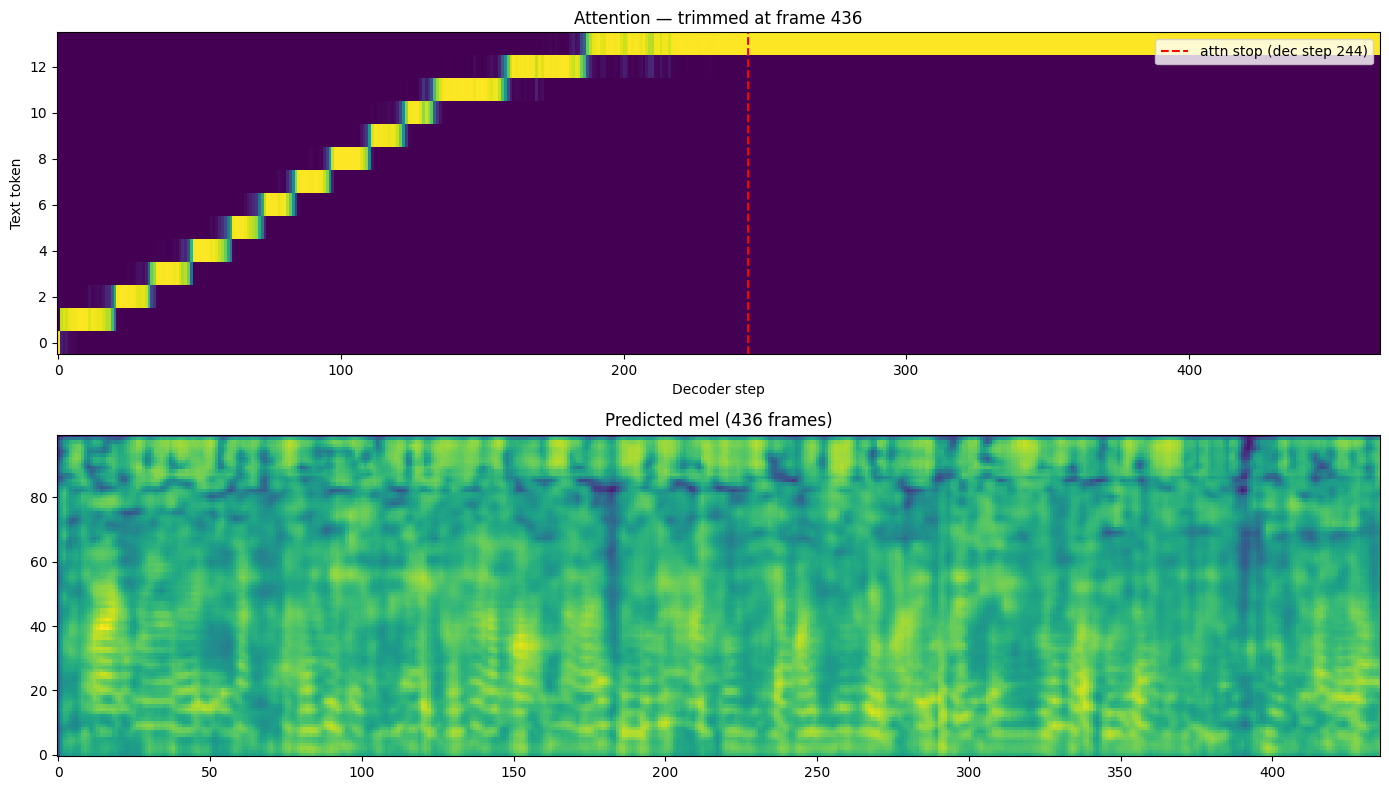

In [4]:
# ============================================================
# Path A v3 inference — with ATTENTION-BASED TRIMMING
# Handles the "stop token undertrained" issue at early checkpoints
# by detecting when attention locks onto the last token.
# ============================================================

inference_image_pa = train_image.pip_install("tokenizers", "matplotlib")


def find_attention_stop(attn_np, lookback_pct=0.1, on_last_threshold=0.5,
                        lock_threshold=0.8, grace_frames=20):
    """
    Find when attention 'locked' on the final text token and stayed there.

    Args:
        attn_np: (T_dec, T_enc) numpy attention matrix
        lookback_pct: size of rolling window as fraction of total decoder steps
        on_last_threshold: attention weight on last token to count as "on it"
        lock_threshold: fraction of window that must be "on last" to count as locked
        grace_frames: extra frames to include after lock point (finish phoneme tail)

    Returns:
        int: frame index where attention locked on last token, or T_dec if never locked
    """
    T_dec, T_enc = attn_np.shape
    if T_enc < 2:
        return T_dec
    last_token_idx = T_enc - 1
    on_last = attn_np[:, last_token_idx] > on_last_threshold
    window = max(10, int(T_dec * lookback_pct))
    for i in range(window, T_dec):
        if on_last[i - window:i].mean() > lock_threshold:
            return min(i + grace_frames, T_dec)
    return T_dec  # never locked — use full


@app.function(image=inference_image_pa, gpu="T4", volumes={"/mnt/sauti": vol})
def msingi_tts_pathA_v2(text="Habari ya leo, jina langu ni Msingi.",
                        taco_step=None, max_decode_seconds=10.0,
                        stop_threshold=0.5,
                        use_attention_stop=True,
                        attn_on_last_threshold=0.5,
                        attn_lock_threshold=0.8,
                        attn_grace_frames=20):
    import os, json, glob, torch, numpy as np
    from bigvgan import BigVGAN
    from huggingface_hub import hf_hub_download
    from tokenizers import Tokenizer

    class AttrDict(dict):
        def __getattr__(self, k): return self[k]

    C = CONFIG
    P = PATHA

    # ---- 1. Tokenize ----
    tok = Tokenizer.from_file(f'{C["tok_dir"]}/tokenizer.json')
    ids = tok.encode(text.lower()).ids
    print(f"Text: '{text}'")
    print(f"MsingiTokens ({len(ids)}): {ids[:20]}{'...' if len(ids)>20 else ''}")

    # ---- 2. Load Tacotron 2 ----
    if taco_step:
        tp = f'{P["ckpt_dir"]}/taco_{taco_step:06d}.pt'
    else:
        cks = sorted(glob.glob(f'{P["ckpt_dir"]}/taco_*.pt'))
        tp = cks[-1] if cks else None
    if not tp:
        raise FileNotFoundError("No Tacotron 2 checkpoint")
    print(f"Tacotron 2: {tp}")

    taco = build_tacotron2(P).cuda().eval()
    state = torch.load(tp, map_location="cuda")
    if isinstance(state, dict) and "model" in state:
        taco.load_state_dict(state["model"])
        print(f"  Checkpoint: v2 (step {state.get('step', '?')}, "
              f"losses={state.get('losses', {})})")
    else:
        taco.load_state_dict(state)
        print(f"  Checkpoint: v1 (raw state_dict)")

    # ---- 3. Autoregressive decode ----
    tokens = torch.LongTensor(ids).unsqueeze(0).cuda()
    text_lens = torch.LongTensor([len(ids)]).cuda()
    max_steps = int(max_decode_seconds * C["sample_rate"]
                    / C["hop_length"] / P["reduction_factor"])

    with torch.no_grad():
        mel_pre, mel_post, stop_logits, attn = taco(
            tokens, text_lens, target_mel=None, max_steps=max_steps)

    # ---- 4. Determine stop point ----
    # Strategy: compute BOTH stop methods, use earlier (more aggressive).
    # This handles the case where stop token is undertrained at early steps.

    stop_probs = torch.sigmoid(stop_logits[0]).cpu().numpy()  # (T_mel,)
    attn_np = attn[0].detach().float().cpu().numpy()           # (T_dec, T_enc)
    T_mel = len(stop_probs)
    T_dec = attn_np.shape[0]

    # Method A: stop token threshold crossing
    crosses = np.where(stop_probs > stop_threshold)[0]
    stop_tok_idx = int(crosses[0]) if len(crosses) > 0 else T_mel

    # Method B: attention-based trimming
    if use_attention_stop:
        attn_stop_dec = find_attention_stop(
            attn_np,
            on_last_threshold=attn_on_last_threshold,
            lock_threshold=attn_lock_threshold,
            grace_frames=attn_grace_frames,
        )
        # Decoder step → mel frame: each decoder step = reduction_factor frames
        attn_stop_mel = attn_stop_dec * P["reduction_factor"]
    else:
        attn_stop_mel = T_mel

    # Combine — use earlier of the two
    final_stop = min(stop_tok_idx, attn_stop_mel)
    # Safety floor: never truncate to less than 20 frames
    final_stop = max(final_stop, 20)

    hop = C["hop_length"]
    sr = C["sample_rate"]
    print(f"\nStop detection:")
    print(f"  stop token method: frame {stop_tok_idx}/{T_mel} "
          f"(~{stop_tok_idx * hop / sr:.2f}s)")
    print(f"  attention method:  frame {attn_stop_mel}/{T_mel} "
          f"(~{attn_stop_mel * hop / sr:.2f}s)")
    print(f"  USING:             frame {final_stop}/{T_mel} "
          f"(~{final_stop * hop / sr:.2f}s)")

    mel_final = mel_post[:, :, :final_stop]

    print(f"\nFinal mel: shape={tuple(mel_final.shape)}")
    print(f"  range=[{float(mel_final.min()):.2f}, {float(mel_final.max()):.2f}]")
    print(f"  mean={float(mel_final.mean()):.2f}")

    # ---- 5. Vocode ----
    cfg = hf_hub_download(repo_id=C["bigvgan_repo"], filename="config.json")
    with open(cfg) as f:
        h = AttrDict(json.load(f))
    vcks = sorted(glob.glob(f'{C["ckpt_dir"]}/gen_*.pt'))
    vp = vcks[-1]
    print(f"Vocoder: {vp}")
    vocoder = BigVGAN(h).cuda().eval()
    vocoder.load_state_dict(torch.load(vp, map_location="cuda"))

    with torch.no_grad():
        wav = vocoder(mel_final.float()).squeeze().cpu().numpy()

    print(f"\nWav: len={len(wav)} ({len(wav)/sr:.2f}s)")
    print(f"  abs_max={np.abs(wav).max():.4f} rms={np.sqrt((wav**2).mean()):.4f}")

    return {
        "text": text,
        "tokens": ids,
        "wav": wav.astype(np.float32),
        "sample_rate": sr,
        "stop_tok_idx": stop_tok_idx,
        "attn_stop_idx": int(attn_stop_mel),
        "final_stop": int(final_stop),
        "stop_probs": stop_probs.astype(np.float32),
        "attn": attn_np,
        "mel": mel_final[0].float().cpu().numpy(),
    }


# ============================================================
# Usage
# ============================================================
with app.run():
    out = msingi_tts_pathA_v2.remote(
         text="Habari ya leo, jina langu ni Msingi, na ninatoka Kenya."
   )

from IPython.display import Audio, display
import matplotlib.pyplot as plt

print(out["text"])
display(Audio(out["wav"], rate=out["sample_rate"]))
# # Visualize
fig, ax = plt.subplots(2, 1, figsize=(14, 8))
ax[0].imshow(out["attn"].T, aspect="auto", origin="lower", interpolation="none")
ax[0].axvline(out["attn_stop_idx"] // 2, color='r', linestyle='--',
               label=f'attn stop (dec step {out["attn_stop_idx"]//2})')
ax[0].set_title(f"Attention — trimmed at frame {out['final_stop']}")
ax[0].set_xlabel("Decoder step")
ax[0].set_ylabel("Text token")
ax[0].legend()
ax[1].imshow(out["mel"], aspect="auto", origin="lower")
ax[1].set_title(f"Predicted mel ({out['mel'].shape[1]} frames)")
plt.tight_layout()
plt.show()

# # Also try disabling attention trimming to hear the untrimmed version
with app.run():
     out_raw = msingi_tts_pathA_v2.remote(
        text="Habari ya leo, jina langu ni Msingi, na ninatoka Kenya.",
         use_attention_stop=False,
    )
display(Audio(out_raw["wav"], rate=out_raw["sample_rate"]))

## Phase 3: WAXAL Alignment (Future)

After Phase 2 reaches 100k:

1. Create `/mnt/sauti/v11/waxal/` subdirectory
2. Load WAXAL Swahili (elite coastal dialects)
3. Continue GAN from latest Phase 2 ckpt with:
   - Lower LR (5e-5)
   - Fmap weight bumped to 5.0 for dialect detail
   - Speaker conditioning if multi-speaker
4. Zero-shot eval on held-out Bajuni + Chidigo speakers
5. Compare mel reconstruction fidelity vs Phase 2 baseline

Separate notebook. Do not start until Phase 2 is stable at 100k.
